## ``Dimensionality Reduction - Video Games``

##### ``Sandra Ranilla-Cortina``

In [1]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.style.use('fivethirtyeight')
np.random.seed(777)

import warnings
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = FutureWarning)

#### ``Video Games Pre-Processed Data``

In [2]:
# Titanic Pre-Processed data
X_train = pd.read_pickle('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-IA/data/VideoGames/X_Train_VideoGames.pkl')
X_test = pd.read_pickle('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-IA/data/VideoGames/X_Test_VideoGames.pkl')
Y_train = pd.read_pickle('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-IA/data/VideoGames/Y_Train_VideoGames.pkl')
Y_test = pd.read_pickle('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-IA/data/VideoGames/Y_Test_VideoGames.pkl')

#### ``Principal Component Analysis (PCA)``

In [3]:
# Dimensionality Reduction - PCA
pca = PCA()
x_train_pca = pca.fit_transform(X_train)
x_train_pca.shape

(35830, 15)

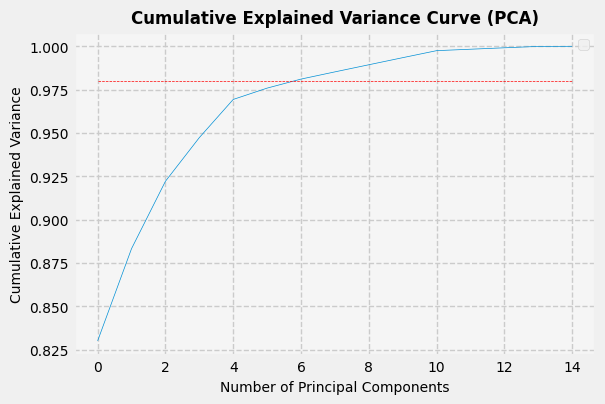

In [4]:
# PCA - Explained Variance Ratio
fig = plt.figure(figsize = (6, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
plt.plot(pca.explained_variance_ratio_.cumsum(), linewidth = 0.5)
plt.plot(np.ones((X_train.shape[1], 1)) * 0.98, 'r--', linewidth = 0.5)
plt.grid(linestyle = '--')
plt.title('Cumulative Explained Variance Curve (PCA)', fontsize = 12, fontweight = 'bold')
plt.ylabel('Cumulative Explained Variance', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
plt.xlabel('Number of Principal Components', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5)
# Number of components to consider (>98% variance explained - aprox. 6)

In [5]:
# Dimensionality Reduction - PCA
pca = PCA(n_components = 6)
X_train_pca = pca.fit_transform(X_train)
X_train_pca = pd.DataFrame(X_train_pca, columns = [f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_train_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6
0,13.338119,-4.491634,1.430747,-0.099763,3.045406,-0.977897
1,-1.262113,6.519112,-5.480288,0.851111,-2.025285,1.004735
2,14.320838,-0.533889,1.436665,-3.101022,1.979336,2.056157
3,7.788921,-3.528816,-5.526037,-2.067617,0.890710,0.028521
4,23.358139,4.471667,5.426795,-3.127021,0.039761,1.096208


In [6]:
# PCA transformation to the test data
X_test_pca = pca.transform(X_test)
X_test_pca = pd.DataFrame(X_test_pca, columns = [f'PC{i+1}' for i in range(X_test_pca.shape[1])])
print(X_train_pca.shape, X_test_pca.shape)

(35830, 6) (11944, 6)


In [7]:
# Save to pickle 
X_train_pca.to_pickle('../../data/VideoGames/X_Train_PCA_VideoGames.pkl')
X_test_pca.to_pickle('../../data/VideoGames/X_Test_PCA_VideoGames.pkl')

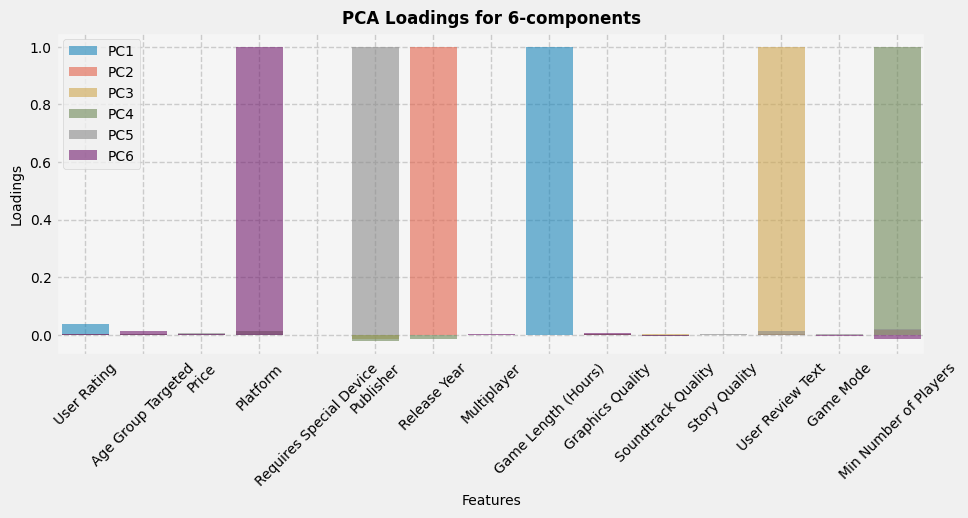

In [8]:
# Loadings (coefficients) for PCA components
loadings = pca.components_
loadings_df = pd.DataFrame(loadings.T, columns = [f'PC{i+1}' for i in range(6)], index = X_train.columns)

# Visualization
fig = plt.figure(figsize = (10, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
for i in range(6):
    sns.barplot(x = loadings_df.index, y = loadings_df[f'PC{i+1}'], label=f'PC{i+1}', alpha=0.6)
plt.grid(linestyle = '--')
plt.title('PCA Loadings for 6-components', fontsize = 12, fontweight = 'bold')
plt.ylabel('Loadings', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
plt.xlabel('Features', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
plt.xticks(rotation = 45)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper left')
legend.get_frame().set_linewidth(0.5)